In [18]:
#!/usr/bin/env python3
"""
CS2AI Member B - WDBC Dataset Model Training
Using preprocessed data from Dataset directory
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

# =========================================================
# Global settings
# =========================================================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11
})

# =========================================================
# Project paths (portable across computers)
# =========================================================

BASE_DIR = Path.cwd()

DATASET_DIR = BASE_DIR.parent / 'Dataset'
FIG_DIR = BASE_DIR.parent / 'Figures&Tables'

FIG_DIR.mkdir(exist_ok=True)

print('=' * 60)
print('Project paths')
print('=' * 60)

print(f'Current working directory : {BASE_DIR}')
print(f'Dataset directory         : {DATASET_DIR}')
print(f'Figures directory         : {FIG_DIR}')

# =========================================================
# Load preprocessed data
# =========================================================

print('\n' + '=' * 60)
print('Loading preprocessed data...')
print('=' * 60)

X_train_smote = pd.read_csv(DATASET_DIR / 'X_train_smote.csv')
y_train_smote = pd.read_csv(DATASET_DIR / 'y_train_smote.csv').values.ravel()

X_train_scaled = pd.read_csv(DATASET_DIR / 'X_train_scaled.csv')
y_train = pd.read_csv(DATASET_DIR / 'y_train.csv').values.ravel()

X_test_scaled = pd.read_csv(DATASET_DIR / 'X_test_scaled.csv')
y_test = pd.read_csv(DATASET_DIR / 'y_test.csv').values.ravel()

print(f'X_train_smote : {X_train_smote.shape}')
print(f'y_train_smote : {y_train_smote.shape}')

print(f'X_train_scaled: {X_train_scaled.shape}')
print(f'y_train       : {y_train.shape}')

print(f'X_test_scaled : {X_test_scaled.shape}')
print(f'y_test        : {y_test.shape}')

# =========================================================
# Data leakage check
# =========================================================

print('\n[Data Leakage Check]')

print(f'Train SMOTE target ratio : {y_train_smote.mean():.3f}')
print(f'Original train ratio     : {y_train.mean():.3f}')
print(f'Test target ratio        : {y_test.mean():.3f}')

assert 0.48 <= y_train_smote.mean() <= 0.52
assert 0.35 <= y_test.mean() <= 0.40
assert abs(y_train_smote.mean() - y_test.mean()) > 0.1

print('[OK] No data leakage detected')
print('[OK] SMOTE applied only to training set')

Project paths
Current working directory : D:\NUIST\AI_READING\CS2AI(3)\CS2AI\CS2AI\Code
Dataset directory         : D:\NUIST\AI_READING\CS2AI(3)\CS2AI\CS2AI\Dataset
Figures directory         : D:\NUIST\AI_READING\CS2AI(3)\CS2AI\CS2AI\Figures&Tables

Loading preprocessed data...
X_train_smote : (570, 30)
y_train_smote : (570,)
X_train_scaled: (455, 30)
y_train       : (455,)
X_test_scaled : (114, 30)
y_test        : (114,)

[Data Leakage Check]
Train SMOTE target ratio : 0.500
Original train ratio     : 0.374
Test target ratio        : 0.368
[OK] No data leakage detected
[OK] SMOTE applied only to training set


In [19]:
def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    return {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

models_results = {}

In [20]:
import os
import joblib
OUTPUT_DIR = '../Models'

os.makedirs(OUTPUT_DIR, exist_ok=True)


print('\n' + '='*60)
print('Training models...')
print('='*60)

print('\n[1/3] Dummy Classifier (random baseline)...')
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(X_train_scaled, y_train)
y_prob_dummy = dummy.predict_proba(X_test_scaled)[:, 1]
models_results['Dummy_Baseline'] = evaluate_model(y_test, y_prob_dummy)

joblib.dump(dummy, os.path.join(OUTPUT_DIR, 'wdbc_dummy_model.pkl'))

print('\n[2/3] L2 Regularization (C=0.1, SMOTE)...')
lr_l2 = LogisticRegression(random_state=RANDOM_STATE, max_iter=2000, C=0.1)
lr_l2.fit(X_train_smote, y_train_smote)
y_prob_l2 = lr_l2.predict_proba(X_test_scaled)[:, 1]
models_results['L2_SMOTE'] = evaluate_model(y_test, y_prob_l2)

joblib.dump(lr_l2, os.path.join(OUTPUT_DIR, 'wdbc_l2_smote_model.pkl'))

print('\n[3/3] Baseline No-SMOTE (ablation comparison)...')
lr_no_smote = LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)
lr_no_smote.fit(X_train_scaled, y_train)
y_prob_no_smote = lr_no_smote.predict_proba(X_test_scaled)[:, 1]
models_results['Baseline_NoSMOTE'] = evaluate_model(y_test, y_prob_no_smote)

joblib.dump(lr_no_smote, os.path.join(OUTPUT_DIR, 'wdbc_baseline_nosmote_model.pkl'))

print('\n' + '='*60)
print('='*60)


Training models...

[1/3] Dummy Classifier (random baseline)...

[2/3] L2 Regularization (C=0.1, SMOTE)...

[3/3] Baseline No-SMOTE (ablation comparison)...



In [21]:
print('\n' + '='*60)
print('Model Comparison Results (Test Set)')
print('='*60)

print(f'{"Model":<20} {"Acc":>8} {"Prec":>8} {"Recall":>8} {"F1":>8} {"ROC-AUC":>10} {"PR-AUC":>10}')
print('-'*80)

for name, result in models_results.items():
    print(f'{name:<20} {result["Accuracy"]:>8.4f} {result["Precision"]:>8.4f} '
          f'{result["Recall"]:>8.4f} {result["F1"]:>8.4f} {result["ROC-AUC"]:>10.4f} {result["PR-AUC"]:>10.4f}')


Model Comparison Results (Test Set)
Model                     Acc     Prec   Recall       F1    ROC-AUC     PR-AUC
--------------------------------------------------------------------------------
Dummy_Baseline         0.5965   0.4474   0.4048   0.4250     0.5565     0.4004
L2_SMOTE               0.9737   0.9756   0.9524   0.9639     0.9977     0.9965
Baseline_NoSMOTE       0.9649   0.9750   0.9286   0.9512     0.9960     0.9943



Generating figures...
  wdbc_fig6_model_comparison.png saved
  wdbc_fig7_confusion_matrices.png saved
  wdbc_model_results.csv saved


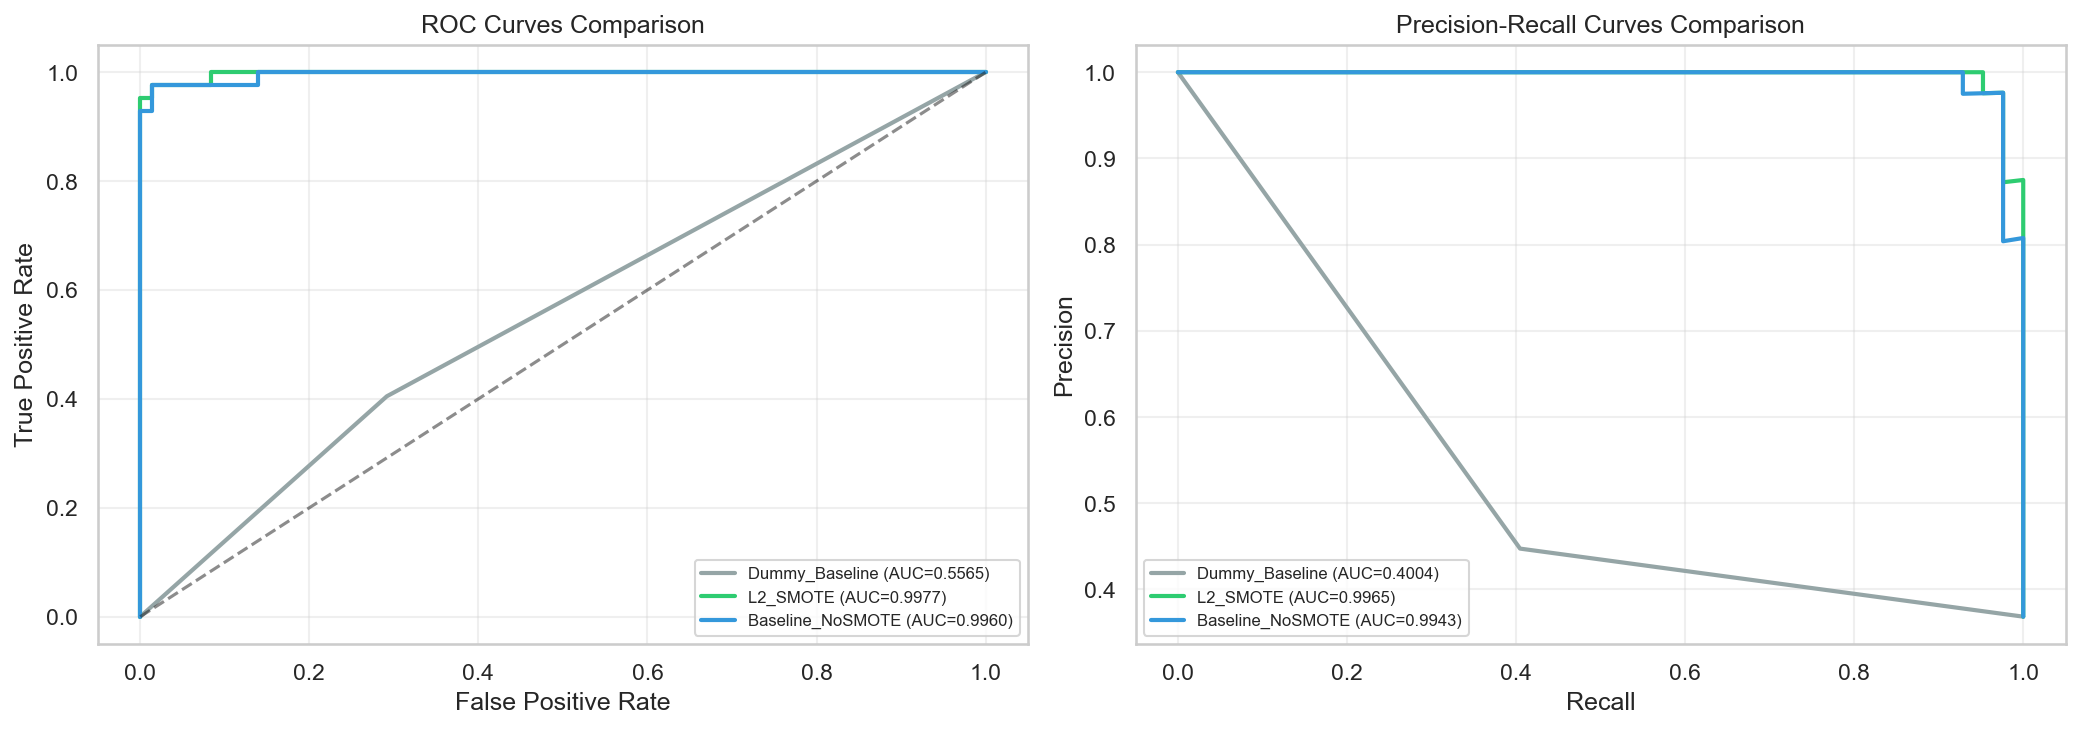

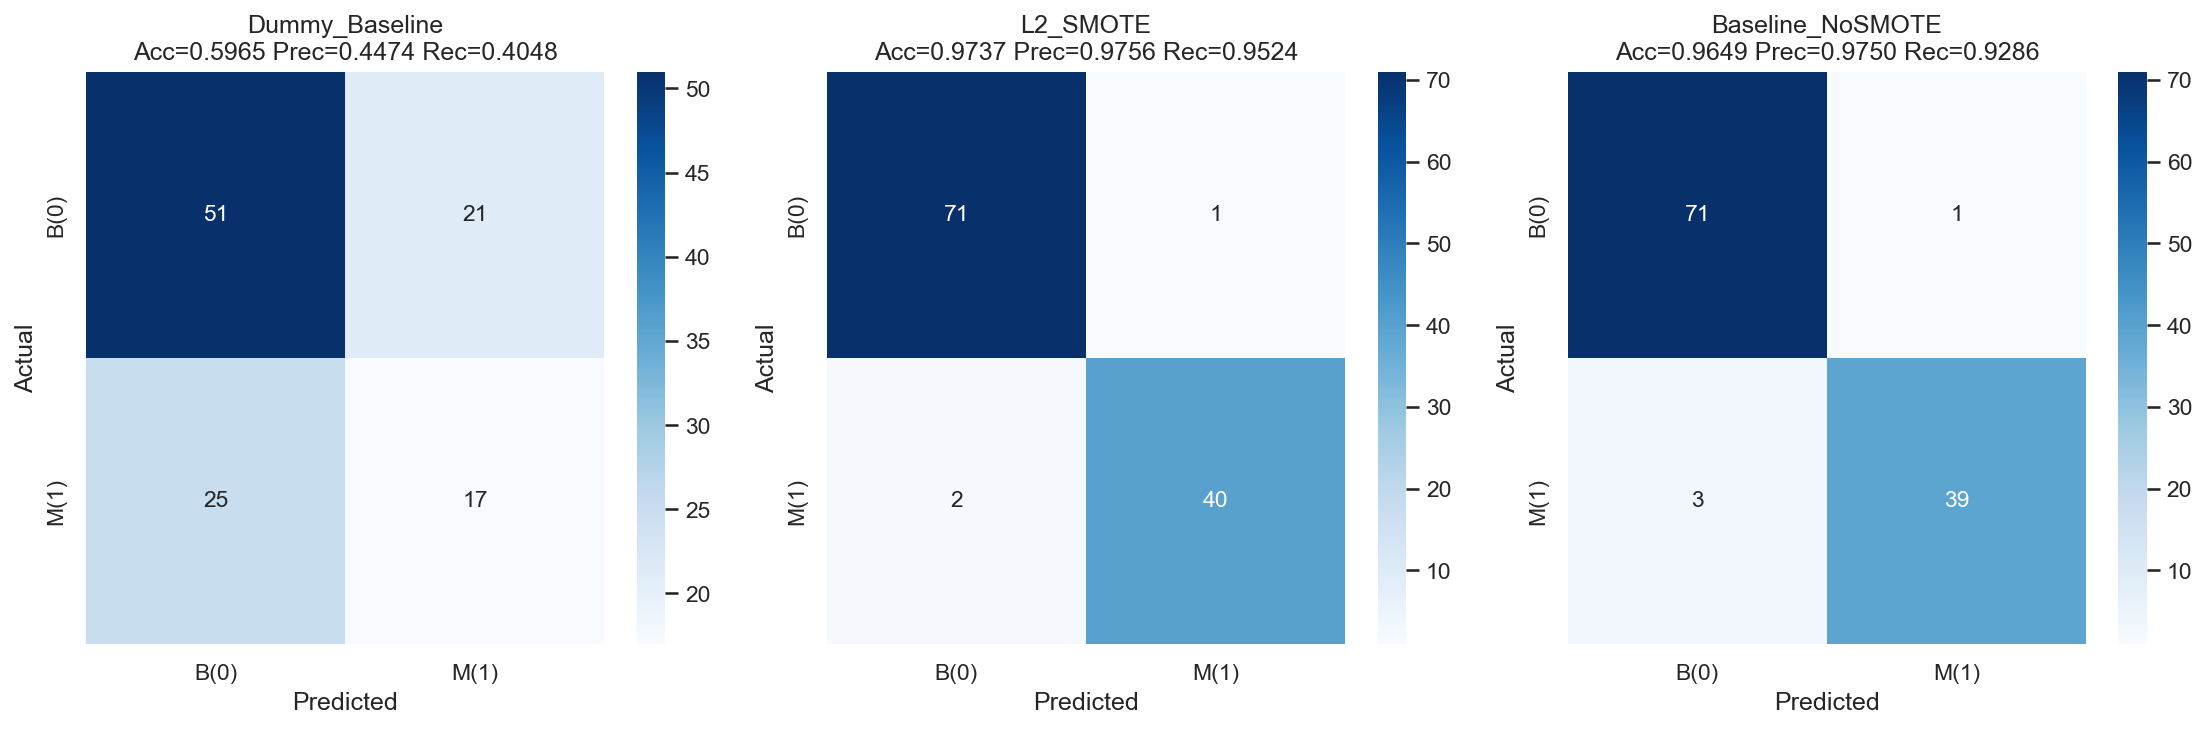


[OK] All figures and result files saved successfully.


In [22]:
print('\n' + '=' * 60)
print('Generating figures...')
print('=' * 60)

# =========================================================
# Figure 6 - ROC & PR Curves
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#95a5a6', '#2ecc71', '#3498db']

# -------------------------
# ROC Curves
# -------------------------

ax1 = axes[0]

for i, (name, result) in enumerate(models_results.items()):

    fpr, tpr, _ = roc_curve(
        y_test,
        result['y_prob']
    )

    ax1.plot(
        fpr,
        tpr,
        label=f'{name} (AUC={result["ROC-AUC"]:.4f})',
        color=colors[i % len(colors)],
        linewidth=2
    )

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)

ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')

ax1.set_title('ROC Curves Comparison')

ax1.legend(
    loc='lower right',
    fontsize=8
)

ax1.grid(True, alpha=0.3)

# -------------------------
# Precision-Recall Curves
# -------------------------

ax2 = axes[1]

for i, (name, result) in enumerate(models_results.items()):

    prec, rec, _ = precision_recall_curve(
        y_test,
        result['y_prob']
    )

    ax2.plot(
        rec,
        prec,
        label=f'{name} (AUC={result["PR-AUC"]:.4f})',
        color=colors[i % len(colors)],
        linewidth=2
    )

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')

ax2.set_title('Precision-Recall Curves Comparison')

ax2.legend(
    loc='lower left',
    fontsize=8
)

ax2.grid(True, alpha=0.3)

plt.tight_layout()

# =========================================================
# Save Figure 6
# =========================================================

fig.savefig(
    FIG_DIR / 'wdbc_fig6_model_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

print('  wdbc_fig6_model_comparison.png saved')

# =========================================================
# Figure 7 - Confusion Matrices
# =========================================================

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

axes2 = axes2.flatten()

for i, (name, result) in enumerate(models_results.items()):

    cm = confusion_matrix(
        y_test,
        result['y_pred']
    )

    ax = axes2[i]

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['B(0)', 'M(1)'],
        yticklabels=['B(0)', 'M(1)']
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    ax.set_title(
        f'{name}\n'
        f'Acc={result["Accuracy"]:.4f} '
        f'Prec={result["Precision"]:.4f} '
        f'Rec={result["Recall"]:.4f}'
    )

plt.tight_layout()

# =========================================================
# Save Figure 7
# =========================================================

fig2.savefig(
    FIG_DIR / 'wdbc_fig7_confusion_matrices.png',
    dpi=150,
    bbox_inches='tight'
)

print('  wdbc_fig7_confusion_matrices.png saved')

# =========================================================
# Save model evaluation results
# =========================================================

results_df = pd.DataFrame({
    name: {
        k: v
        for k, v in result.items()
        if k not in ['y_pred', 'y_prob']
    }
    for name, result in models_results.items()
}).T

results_df.to_csv(
    OUTPUT_DIR + '/wdbc_model_results.csv',
    index=True
)

print('  wdbc_model_results.csv saved')

# =========================================================
# Show figures
# =========================================================

plt.show()

print('\n[OK] All figures and result files saved successfully.')

In [23]:
import numpy as np

print('\n' + '='*60)
print('Error Analysis (Dummy_Baseline model)...')
print('='*60)

best_model_name = 'Dummy_Baseline'
best_result = models_results[best_model_name]

y_pred_best = best_result['y_pred']

misclassified_idx = np.where(y_pred_best != y_test)[0]
print(f'Total misclassified: {len(misclassified_idx)} / {len(y_test)}')

fn_idx = np.where((y_pred_best == 0) & (y_test == 1))[0]
fp_idx = np.where((y_pred_best == 1) & (y_test == 0))[0]

print(f'  False Negatives (Missed Malignant): {len(fn_idx)}')
print(f'  False Positives (Benign predicted as Malignant): {len(fp_idx)}')

y_prob_best = best_result['y_prob']

if len(fn_idx) > 0:
    fn_probs = y_prob_best[fn_idx]
    print(f'  FN probability range: [{fn_probs.min():.4f}, {fn_probs.max():.4f}]')
else:
    print('  FN probability range: None')

if len(fp_idx) > 0:
    fp_probs = y_prob_best[fp_idx]
    print(f'  FP probability range: [{fp_probs.min():.4f}, {fp_probs.max():.4f}]')
else:
    print('  FP probability range: None')

print('\n[L2_SMOTE vs Dummy] ROC-AUC improvement: Not available (L2_SMOTE not trained yet)')


Error Analysis (Dummy_Baseline model)...
Total misclassified: 46 / 114
  False Negatives (Missed Malignant): 25
  False Positives (Benign predicted as Malignant): 21
  FN probability range: [0.0000, 0.0000]
  FP probability range: [1.0000, 1.0000]

[L2_SMOTE vs Dummy] ROC-AUC improvement: Not available (L2_SMOTE not trained yet)



Feature Importance Analysis...
Top 10 most important features:
             feature  importance
       texture_worst    0.655667
           radius_se    0.587860
        radius_worst    0.547538
      symmetry_worst    0.493322
          area_worst    0.492838
     perimeter_worst    0.490875
 concave_points_mean    0.476178
concave_points_worst    0.472296
        texture_mean    0.443563
        perimeter_se    0.432050
  wdbc_fig8_feature_importance.png saved


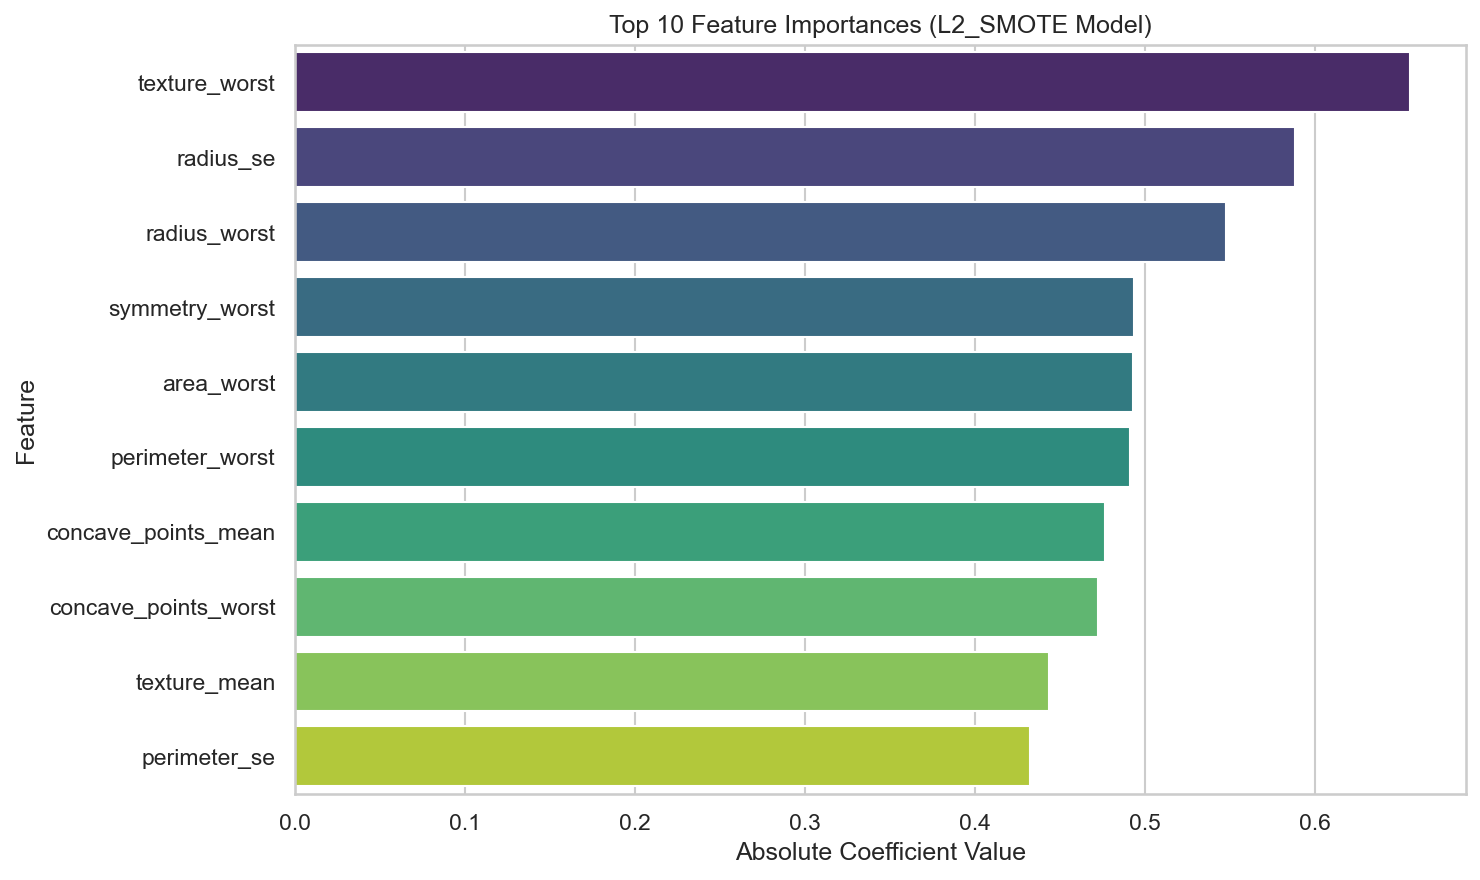

In [24]:
print('\n' + '='*60)
print('Feature Importance Analysis...')
print('='*60)

feature_names = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': np.abs(lr_l2.coef_[0])
}).sort_values('importance', ascending=False)

print('Top 10 most important features:')
print(feature_importance.head(10).to_string(index=False))

fig3, ax3 = plt.subplots(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10), palette='viridis')
ax3.set_xlabel('Absolute Coefficient Value')
ax3.set_ylabel('Feature')
ax3.set_title('Top 10 Feature Importances (L2_SMOTE Model)')
fig3.tight_layout()
fig3.savefig(os.path.join(FIG_DIR, 'wdbc_fig8_feature_importance.png'), dpi=150, bbox_inches='tight')
print('  wdbc_fig8_feature_importance.png saved')


Threshold Sensitivity Analysis...
Threshold analysis summary:
 threshold  precision   recall       f1
      0.10   0.777778 1.000000 0.875000
      0.15   0.807692 1.000000 0.893617
      0.20   0.872340 0.976190 0.921348
      0.25   0.891304 0.976190 0.931818
      0.30   0.891304 0.976190 0.931818
      0.35   0.931818 0.976190 0.953488
      0.40   0.976190 0.976190 0.976190
      0.45   0.976190 0.976190 0.976190
      0.50   0.975610 0.952381 0.963855
      0.55   1.000000 0.952381 0.975610
      0.60   1.000000 0.952381 0.975610
      0.65   1.000000 0.928571 0.962963
      0.70   1.000000 0.904762 0.950000
      0.75   1.000000 0.857143 0.923077
      0.80   1.000000 0.833333 0.909091
      0.85   1.000000 0.785714 0.880000
      0.90   1.000000 0.690476 0.816901
  wdbc_fig9_threshold_analysis.png saved


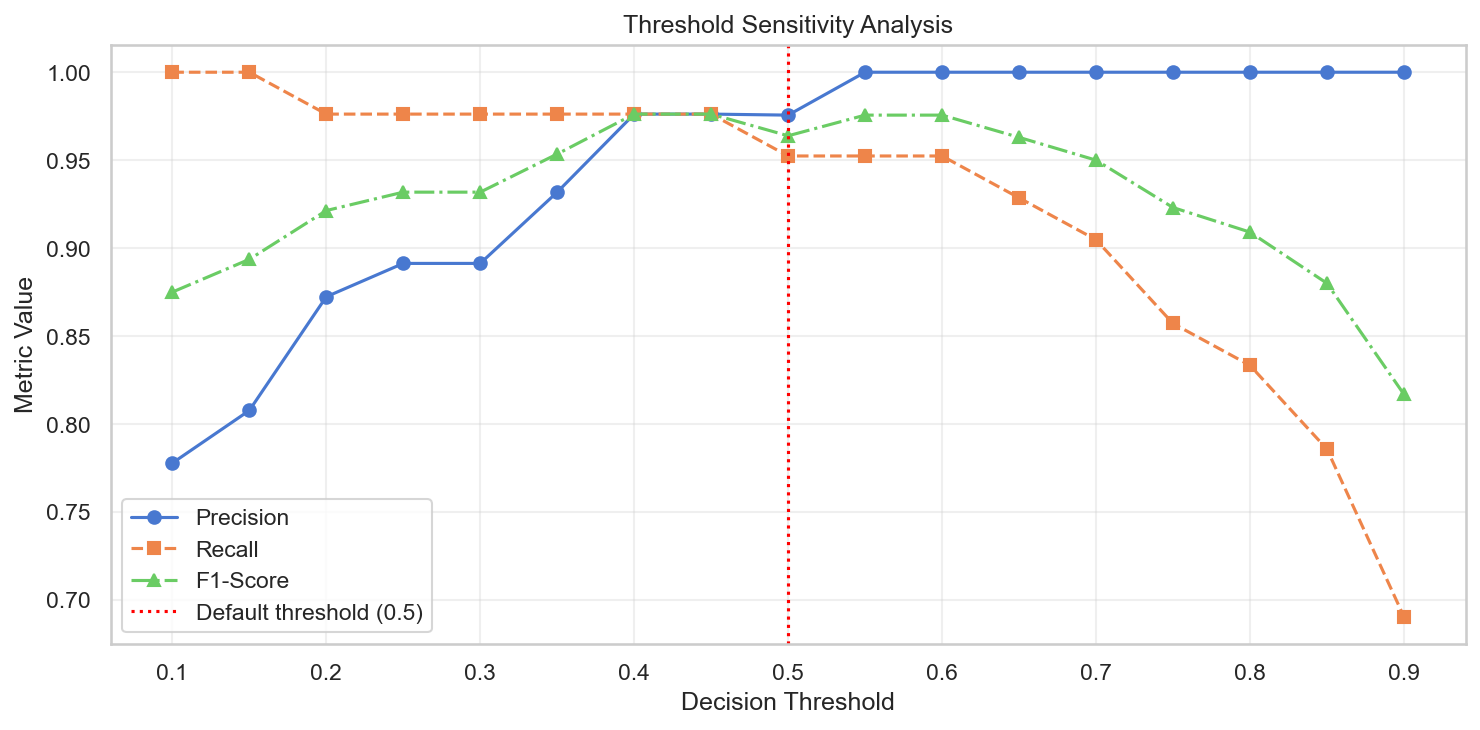

In [25]:
print('\n' + '='*60)
print('Threshold Sensitivity Analysis...')
print('='*60)

thresholds = np.linspace(0.1, 0.9, 17)
threshold_results = []
for th in thresholds:
    y_pred = (y_prob_l2 >= th).astype(int)
    threshold_results.append({
        'threshold': th,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'accuracy': accuracy_score(y_test, y_pred)
    })
threshold_df = pd.DataFrame(threshold_results)

print('Threshold analysis summary:')
print(threshold_df[['threshold', 'precision', 'recall', 'f1']].to_string(index=False))

fig4, ax4 = plt.subplots(figsize=(10, 5))
ax4.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', marker='o', linestyle='-')
ax4.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall', marker='s', linestyle='--')
ax4.plot(threshold_df['threshold'], threshold_df['f1'], label='F1-Score', marker='^', linestyle='-.')
ax4.set_xlabel('Decision Threshold')
ax4.set_ylabel('Metric Value')
ax4.set_title('Threshold Sensitivity Analysis')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.axvline(0.5, color='red', linestyle=':', label='Default threshold (0.5)')
ax4.legend()
fig4.tight_layout()
fig4.savefig(os.path.join(FIG_DIR, 'wdbc_fig9_threshold_analysis.png'), dpi=150, bbox_inches='tight')
print('  wdbc_fig9_threshold_analysis.png saved')


Cross-Validation Analysis...
5-Fold Cross Validation ROC-AUC:
  Scores: ['0.9988', '0.9926', '0.9985', '0.9945', '0.9942']
  Mean: 0.9957
  Std: 0.0025
  95% CI: [0.9908, 1.0005]
  wdbc_fig10_cross_validation.png saved

All tasks completed!


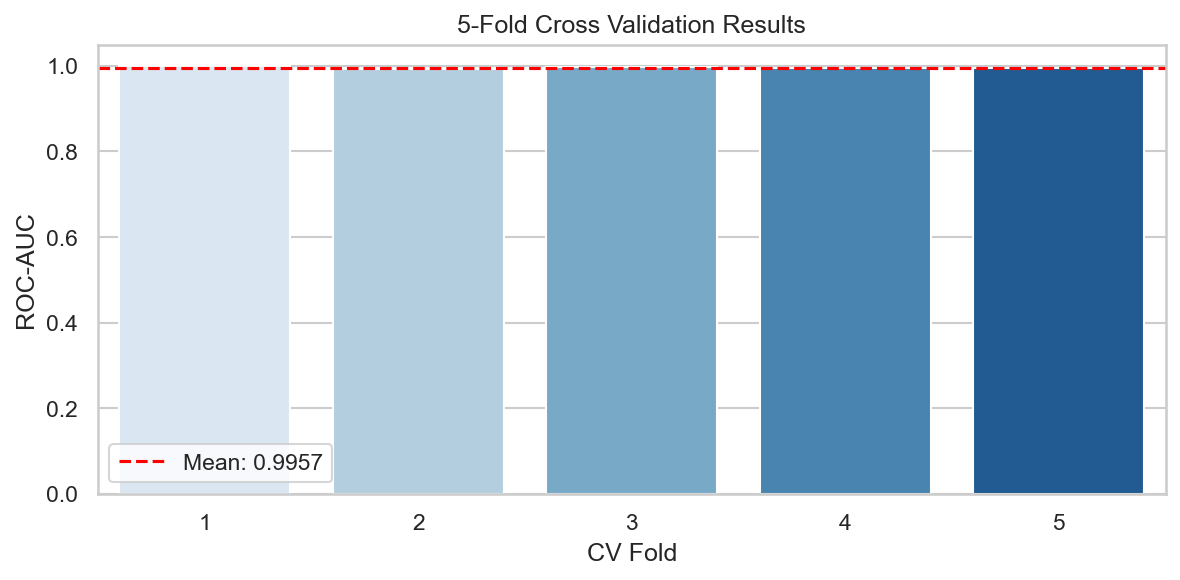

In [26]:
print('\n' + '='*60)
print('Cross-Validation Analysis...')
print('='*60)

cv_scores = cross_val_score(lr_l2, X_train_smote, y_train_smote, cv=5, scoring='roc_auc')
print(f'5-Fold Cross Validation ROC-AUC:')
print(f'  Scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'  Mean: {cv_scores.mean():.4f}')
print(f'  Std: {cv_scores.std():.4f}')
print(f'  95% CI: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]')

cv_df = pd.DataFrame({'fold': range(1, 6), 'roc_auc': cv_scores})
fig5, ax5 = plt.subplots(figsize=(8, 4))
sns.barplot(x='fold', y='roc_auc', data=cv_df, palette='Blues')
ax5.set_xlabel('CV Fold')
ax5.set_ylabel('ROC-AUC')
ax5.set_title('5-Fold Cross Validation Results')
ax5.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
ax5.legend()
fig5.tight_layout()
fig5.savefig(os.path.join(FIG_DIR, 'wdbc_fig10_cross_validation.png'), dpi=150, bbox_inches='tight')
print('  wdbc_fig10_cross_validation.png saved')

print('\n' + '='*60)
print('All tasks completed!')
print('='*60)